# How to compute a functional map between two graphs?

In [1]:
import gsops.backend as gs
import numpy as np
import scipy.sparse

from geomfum.convert import P2pFromFmConverter
from geomfum.descriptor.pipeline import (
    ArangeSubsampler,
    DescriptorPipeline,
    L2InnerNormalizer,
)
from geomfum.descriptor.spectral import LandmarkHeatKernelSignature, WaveKernelSignature
from geomfum.functional_map import FunctionalMap
from geomfum.shape import Graph

## Create two graphs

We create two cycle graphs (ring graphs) with the same number of vertices. The adjacency matrix is built with `scipy.sparse` and then converted to the `gsops` sparse format.

In [2]:
def build_grid_adjacency(n):
    """4-neighbor grid adjacency matrix for n x n grid."""
    N = n * n
    rows, cols = [], []

    def idx(i, j):
        return i * n + j

    for i in range(n):
        for j in range(n):
            if i + 1 < n:
                rows += [idx(i, j), idx(i + 1, j)]
                cols += [idx(i + 1, j), idx(i, j)]
            if j + 1 < n:
                rows += [idx(i, j), idx(i, j + 1)]
                cols += [idx(i, j + 1), idx(i, j)]

    data = np.ones(len(rows))
    return scipy.sparse.csc_matrix((data, (rows, cols)), shape=(N, N))


def make_grid_points(n):
    """Coordinates for n x n grid."""
    x, y = np.meshgrid(np.arange(n), np.arange(n))
    return np.vstack([x.ravel(), y.ravel()]).T


def warp_points(points, strength=0.4):
    """Gentler smooth deformation → closer to isometry."""
    warped = points.copy().astype(float)
    warped[:, 0] += strength * np.sin(points[:, 1] / 3)
    warped[:, 1] += strength * np.sin(points[:, 0] / 3)
    return warped


# -----------------------
# Parameters
# -----------------------
n_side = 10  # 100 nodes

# -----------------------
# SAME adjacency for both
# -----------------------
adj = build_grid_adjacency(n_side)

# -----------------------
# Different embeddings
# -----------------------
pts_a = make_grid_points(n_side)
pts_b = warp_points(pts_a, strength=0.4)  # smaller warp = more isometric

# -----------------------
# Graph objects (same connectivity!)
# -----------------------
graph_a = Graph(adjacency_matrix=gs.sparse.from_scipy_csc(adj))
graph_b = Graph(adjacency_matrix=gs.sparse.from_scipy_csc(adj.copy()))

graph_a.landmark_indices = [0, 22, 55, 99]
graph_b.landmark_indices = [0, 22, 55, 99]

print(graph_a.n_vertices, graph_b.n_vertices)


100 100


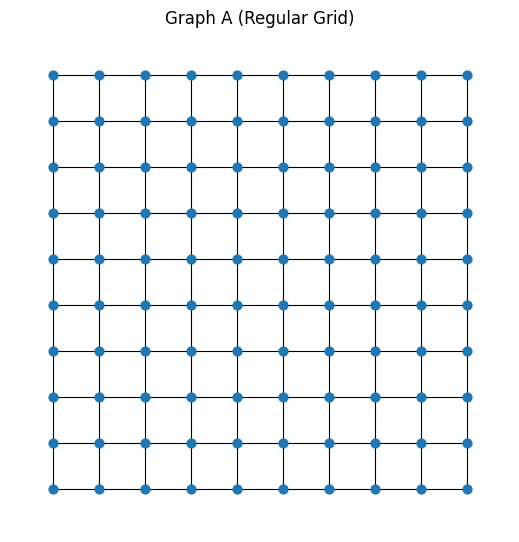

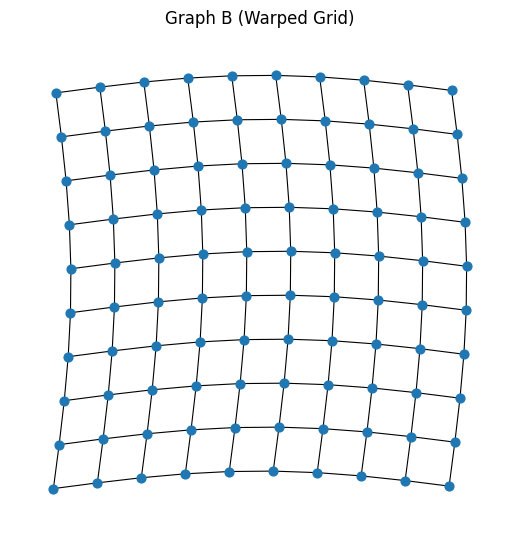

In [3]:
# visualize
import matplotlib.pyplot as plt
import networkx as nx


def nx_from_adj(adj):
    """Convert scipy sparse adjacency to NetworkX graph."""
    return nx.from_scipy_sparse_array(adj)


def plot_graph(G, positions, title="Graph"):
    """Plot a graph with given node positions."""
    plt.figure(figsize=(5, 5))
    nx.draw(
        G,
        pos={i: positions[i] for i in range(len(positions))},
        node_size=40,
        width=0.8,
        with_labels=False,
    )
    plt.title(title)
    plt.axis("equal")
    plt.show()


# Convert to NetworkX
G_a_nx = nx_from_adj(graph_a.adjacency_matrix)
G_b_nx = nx_from_adj(graph_b.adjacency_matrix)
# Plot
plot_graph(G_a_nx, pts_a, "Graph A (Regular Grid)")
plot_graph(G_b_nx, pts_b, "Graph B (Warped Grid)")


## Compute Laplacian spectrum

Compute the Laplacian eigenbasis for each graph. The graph Laplacian $L = D - W$ is used automatically when the shape type is `"graph"`.

In [4]:
graph_a.laplacian.find_spectrum(spectrum_size=99, set_as_basis=True, recompute=True)
graph_b.laplacian.find_spectrum(spectrum_size=99, set_as_basis=True, recompute=True)

graph_a.basis.vals

array([-5.20417043e-18,  2.85980083e-02,  2.85980083e-02,  6.03073792e-02,
        1.10476584e-01,  1.10476584e-01,  1.46555405e-01,  1.46555405e-01,
        2.33955557e-01,  2.34979020e-01,  2.34979020e-01,  2.77186292e-01,
        2.77186292e-01,  3.66593030e-01,  3.66593030e-01,  3.87061781e-01,
        3.87061781e-01,  4.35734867e-01,  4.35734867e-01,  5.00000000e-01,
        5.28487860e-01,  5.28487860e-01,  5.49546864e-01,  5.49546864e-01,
        6.03741128e-01,  6.03741128e-01,  6.62976719e-01,  6.62976719e-01,
        7.00261825e-01,  7.00261825e-01,  7.05141596e-01,  7.05141596e-01,
        7.63253690e-01,  7.63253690e-01,  8.26351822e-01,  8.36271074e-01,
        8.36271074e-01,  8.38608756e-01,  8.38608756e-01,  8.62785420e-01,
        8.62785420e-01,  8.98941633e-01,  8.98941633e-01,  9.38853553e-01,
        9.38853553e-01,  1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
        1.00000000e+00,  1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
        1.00000000e+00,  

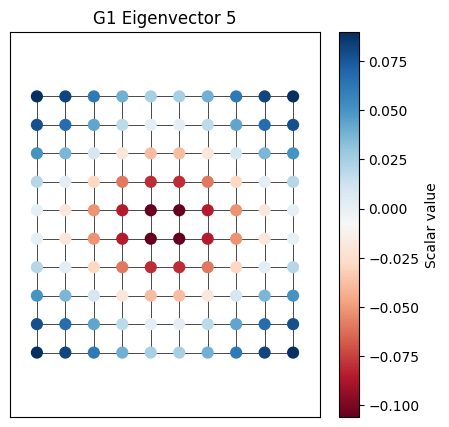

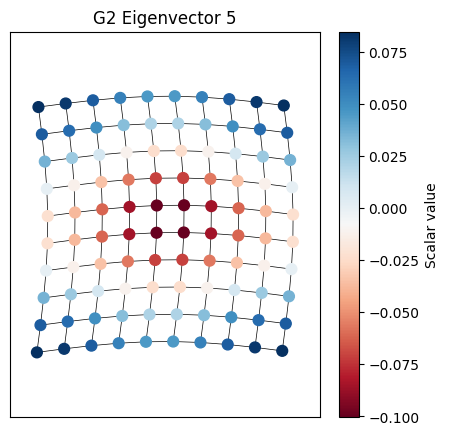

In [5]:
def plot_scalar_on_graph(G, positions, values, title="Scalar Function", cmap="RdBu"):
    """Plot a scalar function on a graph using node colors."""
    plt.figure(figsize=(5, 5))

    nodes = nx.draw_networkx_nodes(
        G,
        pos={i: positions[i] for i in range(len(positions))},
        node_size=60,
        node_color=values,
        cmap=cmap,
    )
    nx.draw_networkx_edges(
        G, pos={i: positions[i] for i in range(len(positions))}, width=0.5
    )

    plt.colorbar(nodes, label="Scalar value")
    plt.title(title)
    plt.axis("equal")
    plt.show()


k = 5
plot_scalar_on_graph(G_a_nx, pts_a, graph_a.basis.vecs[:, k], f"G1 Eigenvector {k}")
plot_scalar_on_graph(G_b_nx, pts_b, graph_b.basis.vecs[:, k], f"G2 Eigenvector {k}")


## Compute descriptors

Use the same descriptor pipeline as for meshes. HKS and WKS are defined purely in terms of the Laplacian eigenvalues and eigenvectors, so they work on any shape type.

In [6]:
steps = [
    LandmarkHeatKernelSignature.from_registry(n_domain=100),
    ArangeSubsampler(subsample_step=2),
    WaveKernelSignature.from_registry(n_domain=100),
    L2InnerNormalizer(),
]

pipeline = DescriptorPipeline(steps)

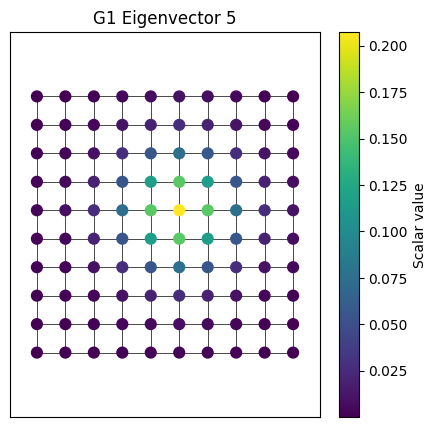

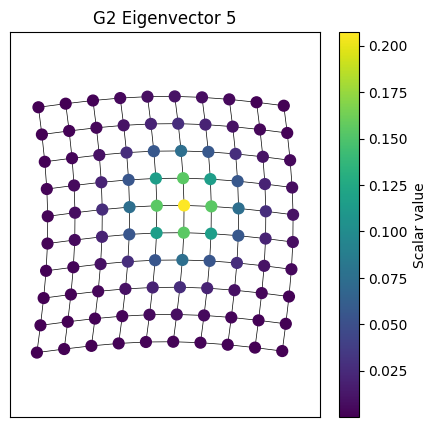

In [7]:
descr_a = pipeline.apply(graph_a)
descr_b = pipeline.apply(graph_b)

descr_a.shape, descr_b.shape


n = 100
plot_scalar_on_graph(G_a_nx, pts_a, descr_a[n], f"G1 Eigenvector {k}", cmap="viridis")
plot_scalar_on_graph(G_b_nx, pts_b, descr_b[n], f"G2 Eigenvector {k}", cmap="viridis")


## Optimize the functional map


In [8]:
fmap_solver = FunctionalMap(fmap_size=(20, 20))
fmap = fmap_solver(graph_a.basis, graph_b.basis, descr_a, descr_b)

fmap.shape

(20, 20)

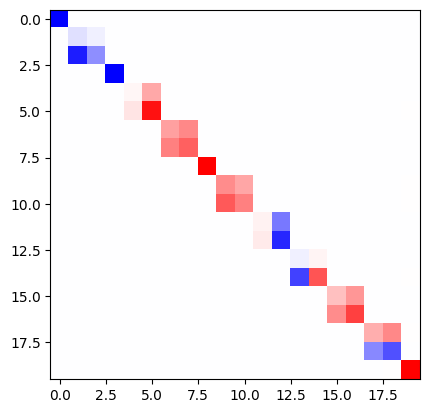

In [9]:
plt.imshow(fmap, cmap="bwr")

## Convert to pointwise map

In [10]:
p2p_converter = P2pFromFmConverter()

p2p = p2p_converter(fmap, graph_a.basis, graph_b.basis)

p2p

array([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90,  1, 11, 21, 31, 41, 51, 61,
       71, 81, 91,  2, 12, 22, 32, 42, 52, 62, 72, 82, 92,  3, 13, 23, 33,
       43, 53, 63, 73, 83, 93,  4, 14, 24, 34, 44, 54, 64, 74, 84, 94,  5,
       15, 25, 35, 45, 55, 65, 75, 85, 95,  6, 16, 26, 36, 46, 56, 66, 76,
       86, 96,  7, 17, 27, 37, 47, 57, 67, 77, 87, 97,  8, 18, 28, 38, 48,
       58, 68, 78, 88, 98,  9, 19, 29, 39, 49, 59, 69, 79, 89, 99])

## Further reading

* [How to compute a functional map?](./07_functional_map.ipynb)
* [How to compute a pointwise map from a functional map?](./10_pointwise_from_functional.ipynb)